<a href="https://colab.research.google.com/github/MarrissaSyokwaa/datascienceprojects/blob/main/PROJECT_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Define the path to the dataset
file_path = '/xyz_inc_salary_prediction.csv'

# Load the dataset using pandas
df = pd.read_csv(file_path)

# Confirmation output
print(f"Dataset successfully loaded. Shape: {df.shape}")
df.head()

Dataset successfully loaded. Shape: (250000, 10)


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10.0,Bachelor,2,Healthcare,Medium,India,Hybrid,2.0,109413.0
1,Data Analyst,5.0,Bachelor,17,Telecom,Small,Australia,No,0.0,93764.0
2,Frontend Developer,18.0,PhD,4,Media,Medium,Singapore,No,NaN,148123.0
3,Business Analyst,19.0,PhD,13,Retail,Medium,Canada,Yes,0.0,189123.0
4,Product Manager,15.0,Bachelor,7,Manufacturing,Large,Sweden,Yes,0.0,165069.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Displaying the first 8 rows
print("First 8 Rows of the Dataset:")
display(df.head(8))

First 8 Rows of the Dataset:


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10.0,Bachelor,2,Healthcare,Medium,India,Hybrid,2.0,109413.0
1,Data Analyst,5.0,Bachelor,17,Telecom,Small,Australia,No,0.0,93764.0
2,Frontend Developer,18.0,PhD,4,Media,Medium,Singapore,No,NaN,148123.0
3,Business Analyst,19.0,PhD,13,Retail,Medium,Canada,Yes,0.0,189123.0
4,Product Manager,15.0,Bachelor,7,Manufacturing,Large,Sweden,Yes,0.0,165069.0
5,AI Engineer,0.0,High School,4,Education,Enterprise,USA,No,2.0,180351.0
6,Backend Developer,6.0,NaN,16,Manufacturing,Enterprise,Canada,No,3.0,165375.0
7,Machine Learning Engineer,NaN,Bachelor,18,Healthcare,Enterprise,Canada,Hybrid,5.0,202463.0


In [ ]:
# Displaying the last 8 rows
print("\nLast 8 Rows of the Dataset:")
display(df.tail(8))


Last 8 Rows of the Dataset:


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
249992,Data Analyst,7.0,NaN,4,Consulting,Large,Netherlands,No,0.0,94870.0
249993,Frontend Developer,17.0,PhD,19,Telecom,Enterprise,Netherlands,Yes,1.0,193028.0
249994,Business Analyst,13.0,Diploma,17,Finance,Large,USA,Yes,3.0,171896.0
249995,Software Engineer,17.0,PhD,2,Telecom,Enterprise,India,No,1.0,127791.0
249996,Frontend Developer,20.0,PhD,7,Telecom,Startup,Remote,No,2.0,154593.0
249997,Business Analyst,1.0,Bachelor,12,Retail,Enterprise,India,Yes,NaN,NaN
249998,Data Scientist,0.0,High School,2,Consulting,Small,Sweden,Hybrid,5.0,90467.0
249999,Data Analyst,16.0,Diploma,2,Technology,Medium,UK,No,5.0,133084.0


In [ ]:
# Reporting the dimensions
rows, columns = df.shape
print(f"Dataset Dimensions: {rows} rows × {columns} columns")

Dataset Dimensions: 250000 rows × 10 columns


In [ ]:
# Displaying data types
print(df.dtypes)

# Counting types
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical ({len(categorical_cols)}): {categorical_cols}")

job_title            object
experience_years    float64
education_level      object
skills_count          int64
industry             object
company_size         object
location             object
remote_work          object
certifications      float64
salary              float64
dtype: object

Numerical (4): ['experience_years', 'skills_count', 'certifications', 'salary']
Categorical (6): ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']


In [ ]:
# Compute descriptive statistics for numerical columns
numerical_summary = df[['experience_years', 'skills_count', 'certifications', 'salary']].describe().T

# Adding median explicitly (though it is equivalent to the 50% quartile)
numerical_summary['median'] = df[['experience_years', 'skills_count', 'certifications', 'salary']].median()

# Reordering columns for clarity
numerical_summary = numerical_summary[['mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max']]
display(numerical_summary)


,mean,median,std,min,25%,50%,75%,max
experience_years,10.046950,10.0,6.322067,-3.0,5.0,10.0,15.00,99.0
skills_count,10.334308,10.0,17.074158,0.0,5.0,10.0,15.00,999.0
certifications,2.491720,2.0,1.706259,0.0,1.0,2.0,4.00,5.0
salary,152721.665606,143447.0,248362.531573,5.0,119308.0,143447.0,169511.25,9999999.0


In [ ]:
# List of categorical columns to analyze
categorical_cols = ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']

# Loop through and display value counts for each
for col in categorical_cols:
    print(f"--- Unique Value Counts for: {col} ---")
    print(df[col].value_counts(dropna=False))
    print("\n")

--- Unique Value Counts for: job_title ---
job_title
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633
Name: count, dtype: int64


--- Unique Value Counts for: education_level ---
education_level
Master         45969
High School    45749
Bachelor       45684
Diploma        45610
PhD            45488
NaN            20000
MASTER           187
diploma          185
Mater            176
PHD              169
master           168
phd              168
BACHELOR         151
bachelor         148
high school      148
Name: count, dtype: int64


--- Unique Value Counts for: industry ---
industry
Finance          24764
Consulting       

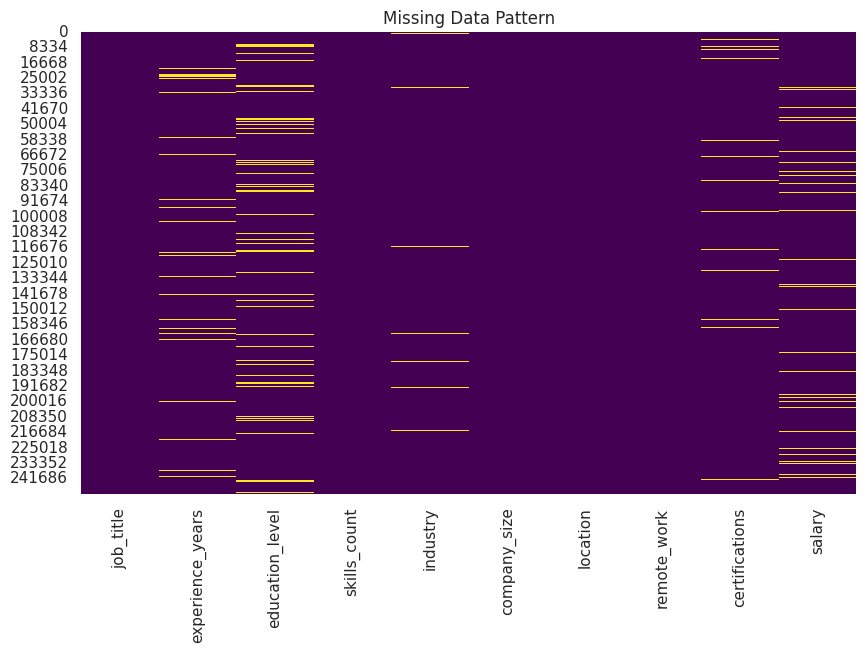

job_title              0
experience_years       0
education_level        0
skills_count           0
industry            4730
company_size           0
location               0
remote_work            0
certifications         0
salary                 0
dtype: int64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Visualize missing values
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Pattern")
plt.show()

# 2. Handling Missing Values
# Drop rows with missing target (salary)
df.dropna(subset=['salary'], inplace=True)

# Impute numerical columns with median
df['experience_years'] = df['experience_years'].fillna(df['experience_years'].median())
df['certifications'] = df['certifications'].fillna(0)

# Impute categorical columns with mode
df['education_level'] = df['education_level'].fillna(df['education_level'].mode()[0])
df['job_title'] = df['job_title'].fillna(df['job_title'].mode()[0])

# 3. Final Check
print(df.isnull().sum())

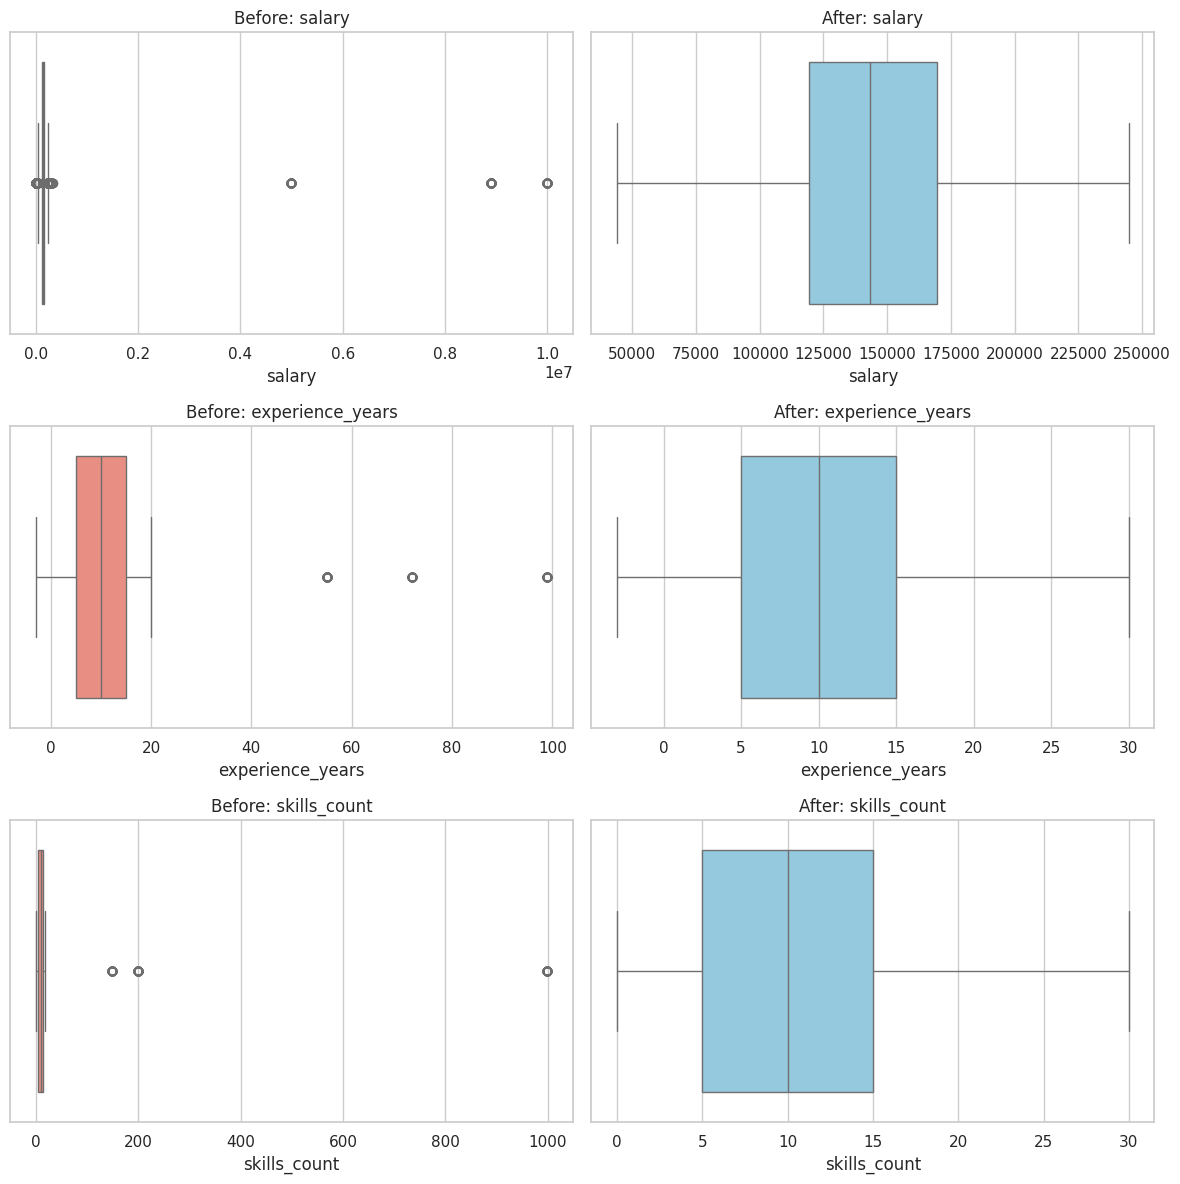

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_to_fix = ['salary', 'experience_years', 'skills_count']

# Create subplots for Before vs After
fig, axes = plt.subplots(len(cols_to_fix), 2, figsize=(12, 12))

for i, col in enumerate(cols_to_fix):
    # Before Plot
    sns.boxplot(x=df[col], ax=axes[i, 0], color='salmon')
    axes[i, 0].set_title(f"Before: {col}")

    # Apply IQR Capping
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_fence, upper=upper_fence)

    # After Plot
    sns.boxplot(x=df[col], ax=axes[i, 1], color='skyblue')
    axes[i, 1].set_title(f"After: {col}")

plt.tight_layout()
plt.show()

In [ ]:
# Correction Code
categorical_cols = ['job_title', 'education_level', 'industry',
                    'company_size', 'location', 'remote_work']

# Standardize and convert
for col in categorical_cols:
    df[col] = df[col].astype(str).str.lower().str.strip().astype('category')

# Ensure Numerical types are explicit
df['salary'] = df['salary'].astype(float)
df['experience_years'] = df['experience_years'].astype(float)
df['skills_count'] = df['skills_count'].astype(int)
df['certifications'] = df['certifications'].astype(float)

In [ ]:
# Function to define salary tiers
def segment_salary(salary):
    if salary >= 200000:
        return 'Elite'
    elif 120000 <= salary < 200000:
        return 'Senior'
    elif 80000 <= salary < 120000:
        return 'Mid'
    else:
        return 'Entry'

# Apply the segmentation
df['SalaryTier'] = df['salary'].apply(segment_salary)

# Ensure the order is logical for the plot
tier_order = ['Elite', 'Senior', 'Mid', 'Entry']
df['SalaryTier'] = pd.Categorical(df['SalaryTier'], categories=tier_order, ordered=True)

/tmp/ipykernel_9051/1031971075.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='SalaryTier', palette='viridis')


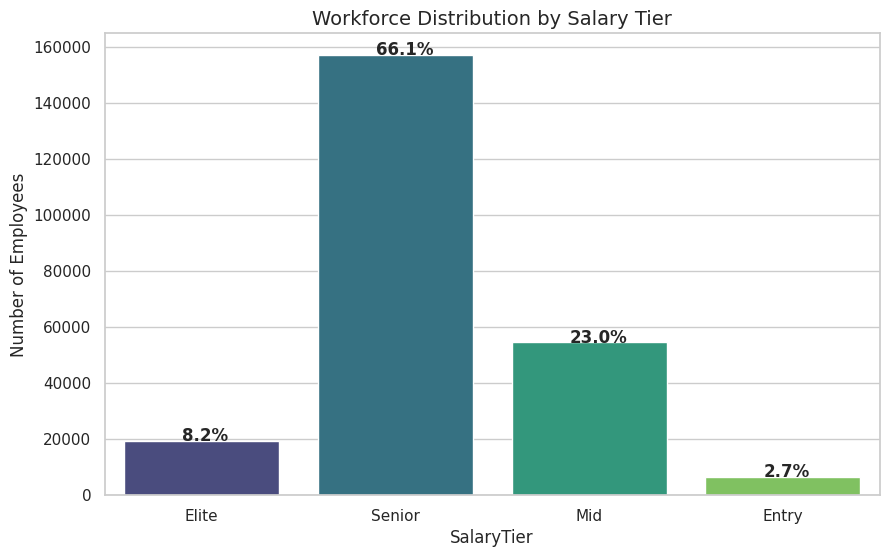

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='SalaryTier', palette='viridis')

# Adding percentage labels
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + 3
    ax.annotate(percentage, (x, y), size=12, fontweight='bold')

plt.title('Workforce Distribution by Salary Tier', fontsize=14)
plt.ylabel('Number of Employees')
plt.show()


In [ ]:
# Function to define career bands
def segment_experience(years):
    if 0 <= years <= 4:
        return 'Junior'
    elif 5 <= years <= 9:
        return 'Mid-level'
    elif 10 <= years <= 14:
        return 'Senior'
    elif 15 <= years <= 20:
        return 'Expert'

# Apply logic and ensure categorical order
df['ExperienceCategory'] = df['experience_years'].apply(segment_experience)
exp_order = ['Junior', 'Mid-level', 'Senior', 'Expert']
df['ExperienceCategory'] = pd.Categorical(df['ExperienceCategory'], categories=exp_order, ordered=True)

# Displaying Value Counts
print(df['ExperienceCategory'].value_counts().sort_index())

ExperienceCategory
Junior       53297
Mid-level    52926
Senior       67227
Expert       63779
Name: count, dtype: int64


In [ ]:
# Create SalaryPerSkill with a guard for zero skills
# If skills_count is 0, we treat it as 1 to avoid division errors or return 0
df['SalaryPerSkill'] = df['salary'] / df['skills_count'].replace(0, 1)

# Displaying the first few rows to verify the calculation
display(df[['salary', 'skills_count', 'SalaryPerSkill']].head())


,salary,skills_count,SalaryPerSkill
0,109413.0,2,54706.500000
1,93764.0,17,5515.529412
2,148123.0,4,37030.750000
3,189123.0,13,14547.923077
4,165069.0,7,23581.285714


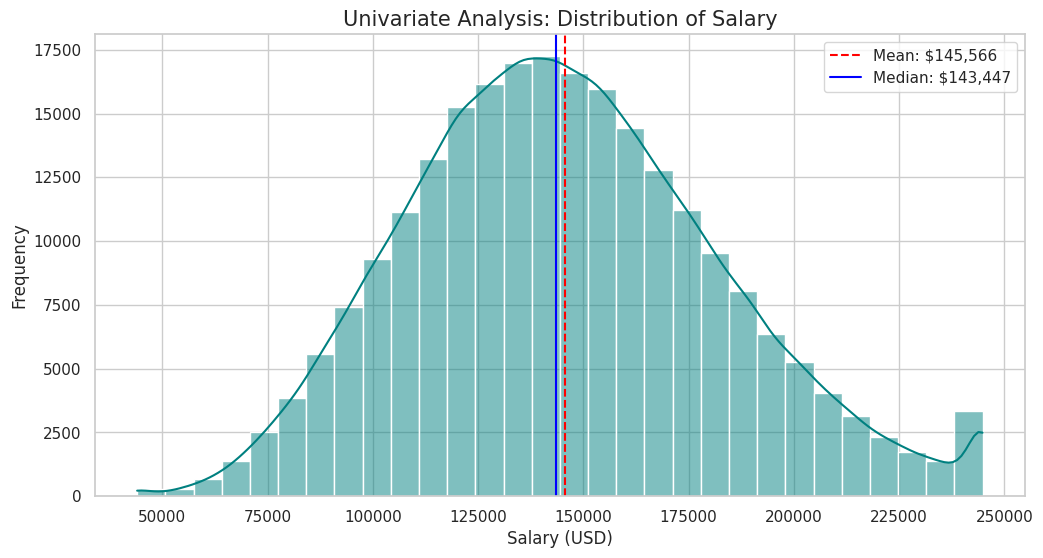

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set aesthetic style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))
# Plotting histogram and KDE
sns.histplot(df['salary'], kde=True, color='teal', bins=30)

# Statistical Annotations
mean_val = df['salary'].mean()
median_val = df['salary'].median()
std_val = df['salary'].std()

plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: ${mean_val:,.0f}')
plt.axvline(median_val, color='blue', linestyle='-', label=f'Median: ${median_val:,.0f}')

plt.title('Univariate Analysis: Distribution of Salary', fontsize=15)
plt.xlabel('Salary (USD)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

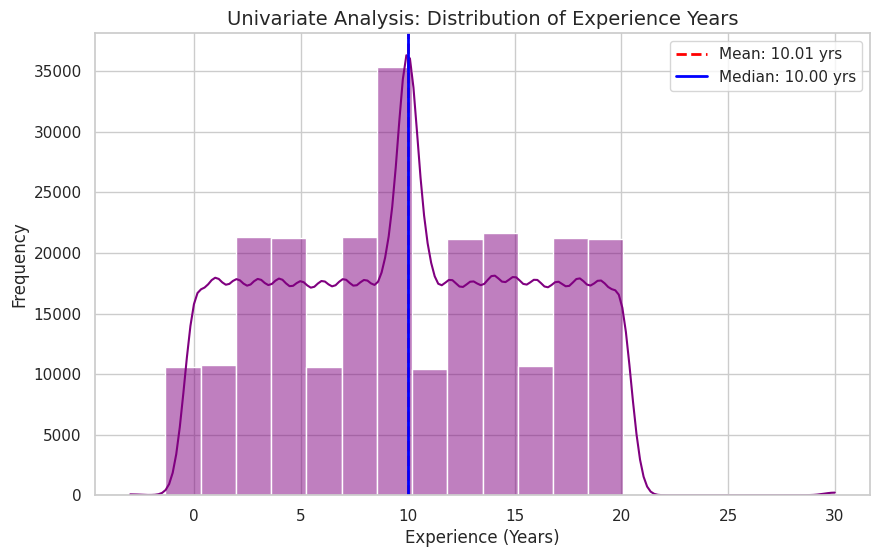

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Plotting histogram and KDE for experience
sns.histplot(df['experience_years'], kde=True, color='purple', bins=20)

# Statistical Annotations
mean_exp = df['experience_years'].mean()
median_exp = df['experience_years'].median()

plt.axvline(mean_exp, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_exp:.2f} yrs')
plt.axvline(median_exp, color='blue', linestyle='-', linewidth=2, label=f'Median: {median_exp:.2f} yrs')

plt.title('Univariate Analysis: Distribution of Experience Years', fontsize=14)
plt.xlabel('Experience (Years)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

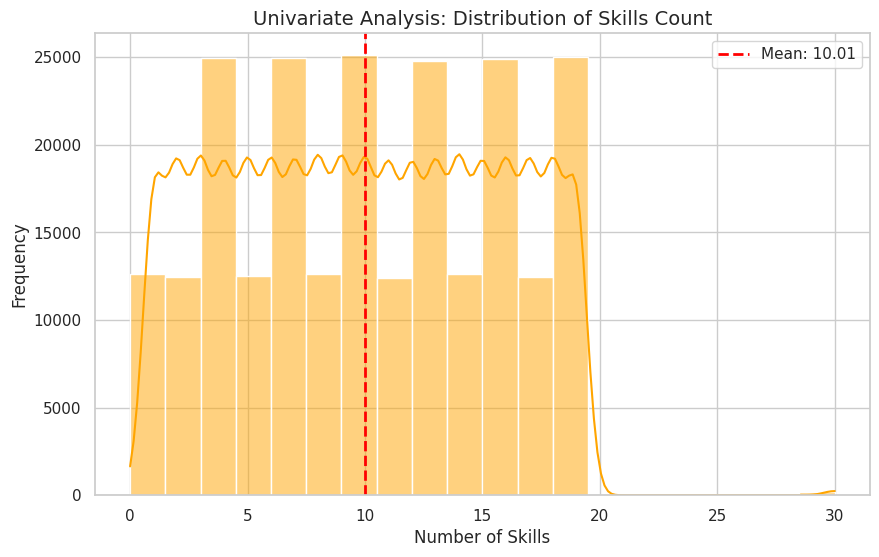

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Plotting histogram and KDE for skills count
sns.histplot(df['skills_count'], kde=True, color='orange', bins=20)

# Statistical Annotation
mean_skills = df['skills_count'].mean()
plt.axvline(mean_skills, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_skills:.2f}')

plt.title('Univariate Analysis: Distribution of Skills Count', fontsize=14)
plt.xlabel('Number of Skills')
plt.ylabel('Frequency')
plt.legend()
plt.show()

/tmp/ipykernel_9051/3078353663.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='remote_work', order=order, palette='Set2')


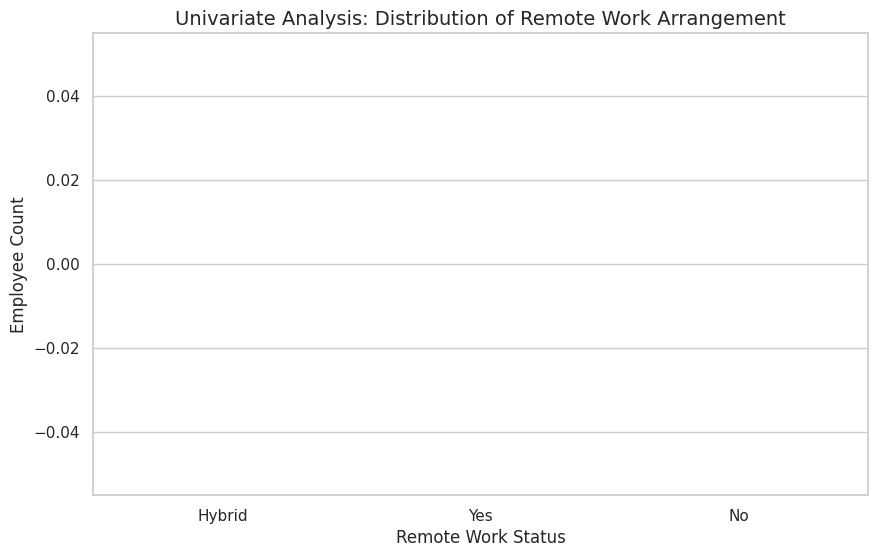

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Plotting the count of each arrangement
order = ['Hybrid', 'Yes', 'No']
ax = sns.countplot(data=df, x='remote_work', order=order, palette='Set2')

# Calculate and annotate percentages
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom',
                fontsize=12, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.title('Univariate Analysis: Distribution of Remote Work Arrangement', fontsize=14)
plt.xlabel('Remote Work Status')
plt.ylabel('Employee Count')
plt.show()

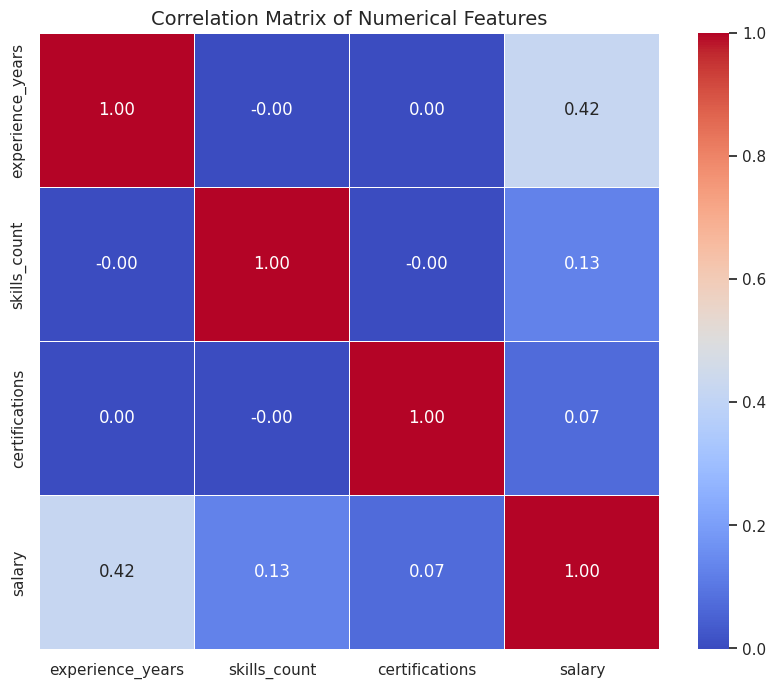

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix
corr_matrix = df[['experience_years', 'skills_count', 'certifications', 'salary']].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=14)
plt.show()

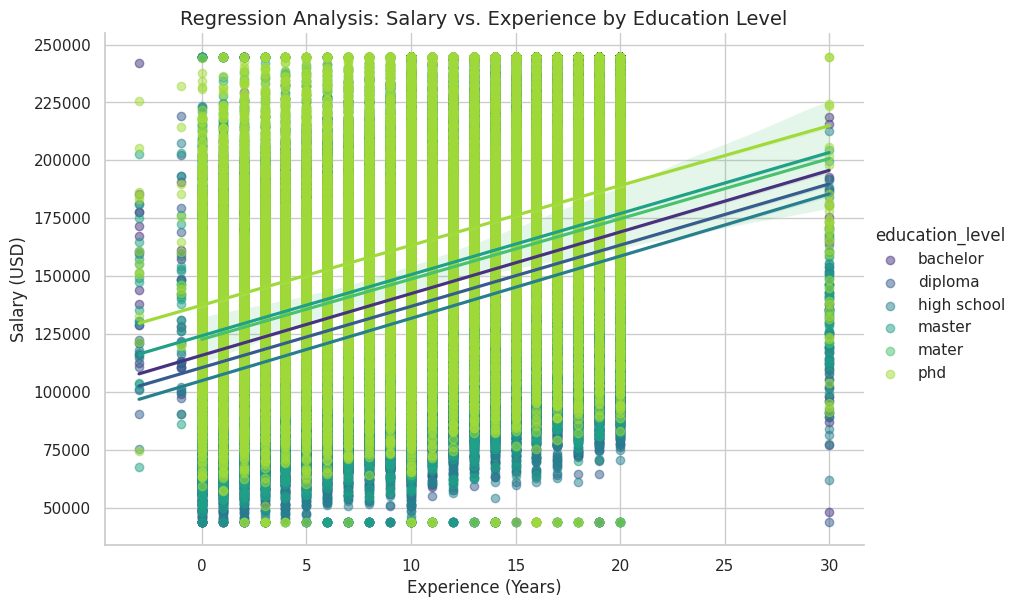

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Creating the multivariate regression plot
g = sns.lmplot(
    data=df,
    x='experience_years',
    y='salary',
    hue='education_level',
    palette='viridis',
    height=6,
    aspect=1.5,
    scatter_kws={'alpha':0.5}
)

plt.title('Regression Analysis: Salary vs. Experience by Education Level', fontsize=14)
plt.xlabel('Experience (Years)')
plt.ylabel('Salary (USD)')
plt.show()

/tmp/ipykernel_9051/932402077.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  job_salary = df.groupby('job_title')['salary'].mean().sort_values(ascending=False)
/tmp/ipykernel_9051/932402077.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_salary.values, y=job_salary.index, palette='magma')


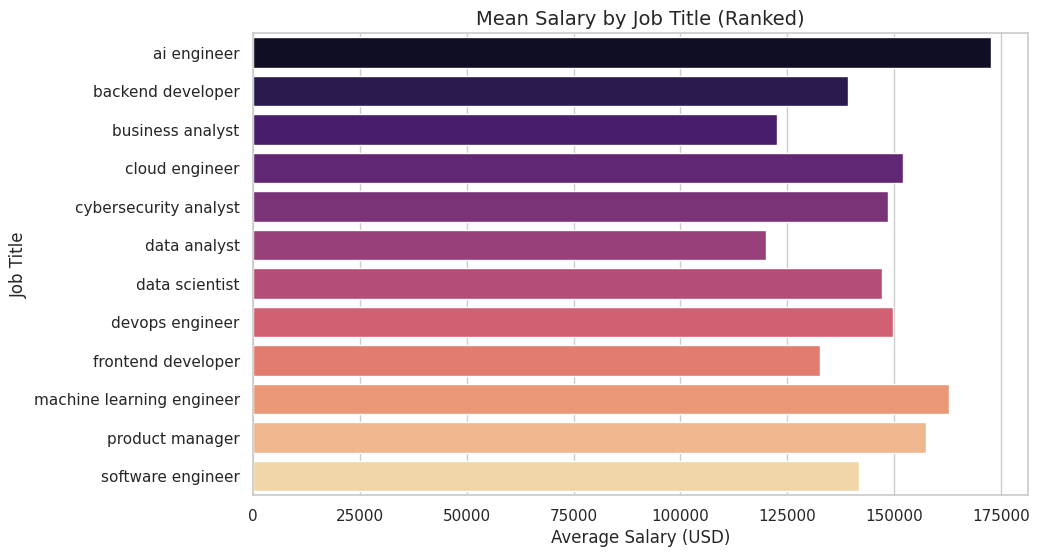

In [ ]:
# Grouping by job_title and calculating mean salary
job_salary = df.groupby('job_title')['salary'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=job_salary.values, y=job_salary.index, palette='magma')
plt.title('Mean Salary by Job Title (Ranked)', fontsize=14)
plt.xlabel('Average Salary (USD)')
plt.ylabel('Job Title')
plt.show()

/tmp/ipykernel_9051/1087559278.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ind_salary = df.groupby('industry')['salary'].mean().sort_values(ascending=False)
/tmp/ipykernel_9051/1087559278.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ind_salary.index, y=ind_salary.values, palette='viridis')


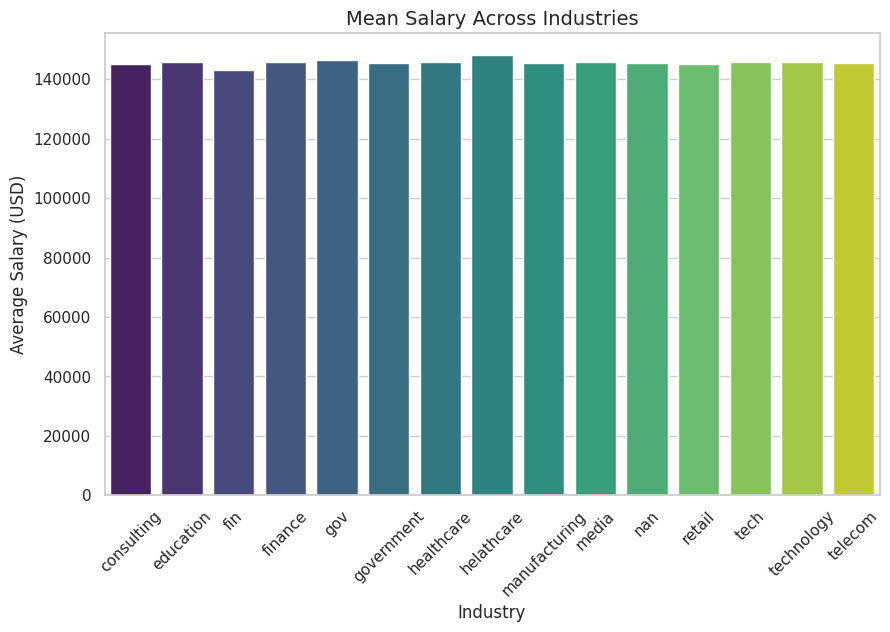

In [ ]:
# Grouping by industry and calculating mean salary
ind_salary = df.groupby('industry')['salary'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=ind_salary.index, y=ind_salary.values, palette='viridis')
plt.title('Mean Salary Across Industries', fontsize=14)
plt.xlabel('Industry')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_9051/453885702.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  edu_salary = df.groupby('education_level')['salary'].mean().sort_values(ascending=False)
/tmp/ipykernel_9051/453885702.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=edu_salary.index, y=edu_salary.values, palette='coolwarm')


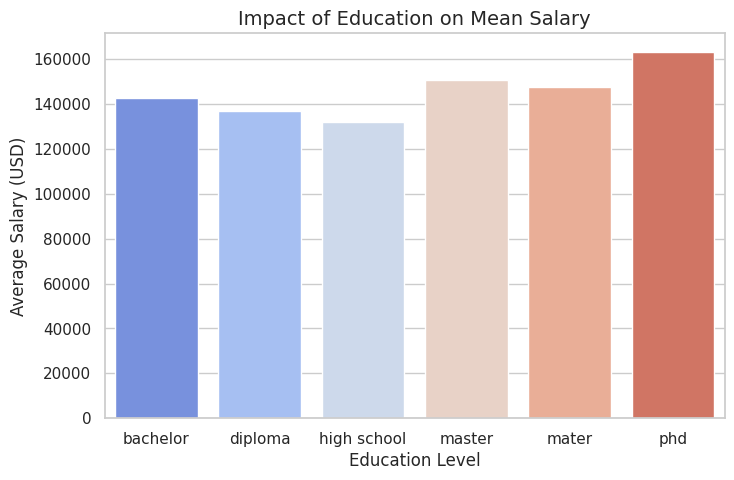

In [ ]:
# Grouping by education_level and calculating mean salary
edu_salary = df.groupby('education_level')['salary'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=edu_salary.index, y=edu_salary.values, palette='coolwarm')
plt.title('Impact of Education on Mean Salary', fontsize=14)
plt.xlabel('Education Level')
plt.ylabel('Average Salary (USD)')
plt.show()


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ['job_title', 'industry', 'education_level']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ], remainder='passthrough')



In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('salary', axis=1)
y = df['salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Train set shape: (190012, 12)
Test set shape: (47504, 12)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Define exactly which columns we want to use (High-level control)
num_cols = ['experience_years', 'skills_count', 'certifications']
cat_cols = ['job_title', 'industry', 'education_level']

# 2. Filter the dataframe to ONLY include these features + the target
# This automatically excludes 'SalaryTier' and any other problematic strings
X = df[num_cols + cat_cols]
y = df['salary']

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Transform the data
# Ensure your preprocessor only looks at cat_cols for encoding and num_cols for scaling
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 5. Initialize and Train
model = LinearRegression()
model.fit(X_train_processed, y_train)

# 6. Evaluation
test_preds = model.predict(X_test_processed)
rmse = np.sqrt(mean_squared_error(y_test, test_preds))
r2 = r2_score(y_test, test_preds)

print(f"Model successfully trained.")
print(f"Test RMSE: ${rmse:,.2f}")
print(f"Test R²: {r2:.4f}")

Model successfully trained.
Test RMSE: $27,965.43
Test R²: 0.4363


/tmp/ipykernel_9051/1545834469.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Blues_r')


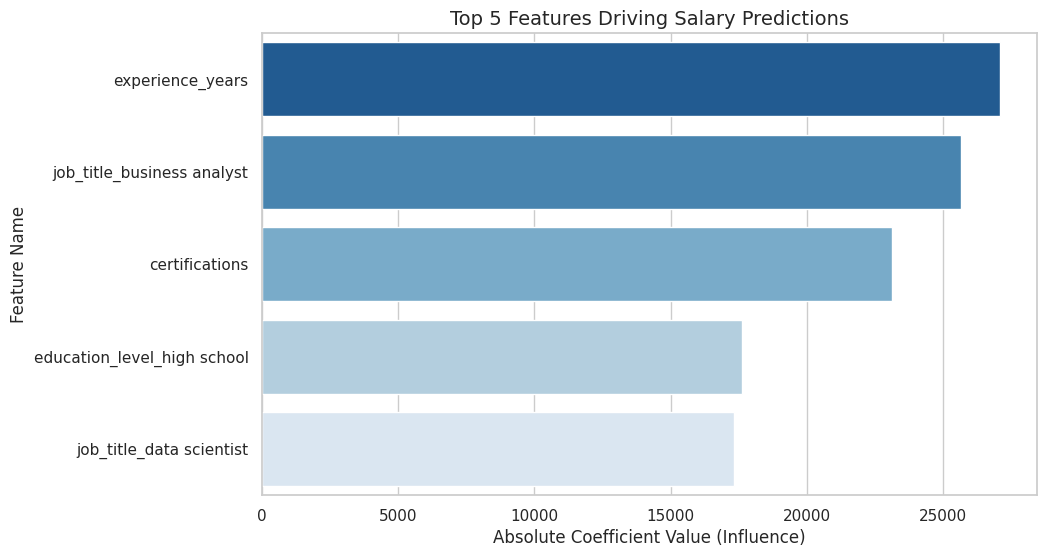

In [ ]:
# Extracting feature names and their corresponding absolute coefficients
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(['job_title', 'industry', 'education_level'])
all_names = np.concatenate([['experience_years', 'skills_count', 'certifications'], cat_names])

importance_df = pd.DataFrame({
    'Feature': all_names,
    'Importance': np.abs(model.coef_)
}).sort_values(by='Importance', ascending=False).head(5)

# Plotting the results
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Blues_r')
plt.title('Top 5 Features Driving Salary Predictions', fontsize=14)
plt.xlabel('Absolute Coefficient Value (Influence)')
plt.ylabel('Feature Name')
plt.show()

In [ ]:
import pickle

# Create a dictionary or a list to store both the transformer and the model
# Alternatively, if you used a Scikit-learn Pipeline object, you can save that directly.
export_data = {
    "preprocessor": preprocessor,
    "model": model
}

# Save to a .pkl file
with open('salary_prediction_pipeline.pkl', 'wb') as file:
    pickle.dump(export_data, file)

print("Model and Preprocessing Pipeline successfully saved to 'salary_prediction_pipeline.pkl'.")


Model and Preprocessing Pipeline successfully saved to 'salary_prediction_pipeline.pkl'.


In [ ]:
# Reload the .pkl file
with open('salary_prediction_pipeline.pkl', 'rb') as file:
    reloaded_objects = pickle.load(file)

# Extract the components
reloaded_preprocessor = reloaded_objects["preprocessor"]
reloaded_model = reloaded_objects["model"]

# Confirm the pipeline steps are intact
print("Reload Confirmation:")
print(f"Preprocessor Steps: {reloaded_preprocessor.transformers_}")
print(f"Model Type: {type(reloaded_model)}")

Reload Confirmation:
Preprocessor Steps: [('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['job_title', 'industry', 'education_level']), ('remainder', FunctionTransformer(accept_sparse=True, check_inverse=False,
                    feature_names_out='one-to-one'), [0, 1, 2])]
Model Type: <class 'sklearn.linear_model._base.LinearRegression'>


In [ ]:
import pandas as pd

# Define the sample employee record
sample_employee = pd.DataFrame({
    'job_title': ['Data Scientist'],
    'experience_years': [8],
    'education_level': ['Master'],
    'skills_count': [12],
    'industry': ['Technology'],
    'company_size': ['Large'],
    'location': ['USA'],
    'remote_work': ['Hybrid'],
    'certifications': [3]
})

# Transform the sample data using the reloaded preprocessor
sample_processed = reloaded_preprocessor.transform(sample_employee)

# Generate the prediction
predicted_salary = reloaded_model.predict(sample_processed)

print(f"--- Prediction Output ---")
print(f"Predicted Salary: ${predicted_salary[0]:,.2f}")

--- Prediction Output ---
Predicted Salary: $143,071.15
